# HFTS-2 well trajectories from the directional surveys

Parses the directional / deviation-survey workbooks for the six HFTS-2 wells
(B1H, B2H, B3H, B4H, B5PH, B6S), computes each **3D trajectory by the
minimum-curvature method** from measured depth, inclination and azimuth, places
each well at its **true surface position** (from the survey lat/long), and plots
the trajectories in 3D, plan (map) view, and vertical section.

The survey files are heterogeneous (`.xls` / `.xlsx` / `.xlsm`, different sheets,
header rows and column names, DMS or decimal lat/long), so the loader below finds
the header row and matches columns by fuzzy name.

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# survey folders (one per well).  Default: the curated copies in research/HFTS-2;
# the packaged snapshot lives at .../FireCuda 4TB/Research/inputs/field_data/well_logs
DATA_ROOT = "../inputs/field_data/well_logs"   # packaged well-logs subset (paths relative to notebooks/)
WELLS = ["B1H", "B2H", "B3H", "B4H", "B5PH", "B6S"]

BASE_FIG_DIR = "../figures/"

## Parsers: survey table + surface lat/long

In [2]:
def _find_header(xl, sheet):
    raw = xl.parse(sheet, header=None, nrows=40)
    for i, row in raw.iterrows():
        j = " ".join(str(c).lower() for c in row.values)
        if "incl" in j and any(k in j for k in ("md", "measured", "depth")):
            return i
    return None

def _surface_latlon(text):
    """Return (lat, lon) in decimal degrees (lon negative = West), or (None, None)."""
    la = re.search(r"latitude[:\s]*(-?\d{1,2}\.\d{3,})", text, re.I)
    lo = re.search(r"longitude[:\s]*(-?\d{1,3}\.\d{3,})", text, re.I)
    if la and lo:
        lat, lon = float(la.group(1)), float(lo.group(1))
        return lat, -abs(lon)
    la = re.search(r"(\d{1,2})[^\d]{1,3}(\d{1,2})['\s][^\d]{0,3}([\d.]+)\"?\s*N", text)
    lo = re.search(r"(\d{2,3})[^\d]{1,3}(\d{1,2})['\s][^\d]{0,3}([\d.]+)\"?\s*[EW]", text)
    if la and lo:
        lat = float(la.group(1)) + float(la.group(2))/60 + float(la.group(3))/3600
        lon = float(lo.group(1)) + float(lo.group(2))/60 + float(lo.group(3))/3600
        return lat, -abs(lon)
    return None, None

def load_survey(well):
    """Return (MD, INC, AZI arrays, lat, lon, filename) for a well, or Nones."""
    for f in sorted(glob.glob(os.path.join(well, "*Survey", "*"))):
        if not f.lower().endswith((".xls", ".xlsx", ".xlsm")):
            continue
        try:
            xl = pd.ExcelFile(f)
        except Exception:
            continue
        for sh in xl.sheet_names:
            hr = _find_header(xl, sh)
            meta = " ".join(xl.parse(sh, header=None, nrows=hr or 19).astype(str).values.flatten())
            lat, lon = _surface_latlon(meta)
            if hr is None:
                continue
            df = xl.parse(sh, header=hr)
            low = {col: str(col).strip().lower() for col in df.columns}
            pick = lambda ks: next((col for col, l in low.items() if any(k in l for k in ks)), None)
            md, inc, az = pick(["measured", "md", "depth"]), pick(["incl"]), pick(["azim", "drift"])
            if md and inc and az:
                s = df[[md, inc, az]].apply(pd.to_numeric, errors="coerce").dropna().sort_values(md)
                if len(s) > 3:
                    return (s[md].to_numpy(), s[inc].to_numpy(), s[az].to_numpy(),
                            lat, lon, os.path.basename(f))
    return None, None, None, None, None, None

## Minimum-curvature trajectory

For successive stations the dogleg angle $\beta$ and ratio factor
$RF=\tfrac{2}{\beta}\tan\tfrac{\beta}{2}$ give the north/east/TVD increments.

In [3]:
def minimum_curvature(md, inc_deg, azi_deg):
    I, A = np.radians(inc_deg), np.radians(azi_deg)
    N = np.zeros(len(md)); E = np.zeros(len(md)); TVD = np.zeros(len(md))
    for k in range(1, len(md)):
        d = md[k] - md[k-1]
        cosb = np.clip(np.cos(I[k]-I[k-1]) - np.sin(I[k-1])*np.sin(I[k])*(1-np.cos(A[k]-A[k-1])), -1, 1)
        beta = np.arccos(cosb)
        rf = 1.0 if beta < 1e-9 else (2.0/beta) * np.tan(beta/2.0)
        N[k]   = N[k-1]   + d/2*(np.sin(I[k-1])*np.cos(A[k-1]) + np.sin(I[k])*np.cos(A[k]))*rf
        E[k]   = E[k-1]   + d/2*(np.sin(I[k-1])*np.sin(A[k-1]) + np.sin(I[k])*np.sin(A[k]))*rf
        TVD[k] = TVD[k-1] + d/2*(np.cos(I[k-1]) + np.cos(I[k]))*rf
    return N, E, TVD

## Load all wells and place them at their true surface positions

In [4]:
wells = {}
for w in WELLS:
    md, inc, az, lat, lon, fname = load_survey(os.path.join(DATA_ROOT, w))   # search the well folder for a survey table
    if md is None:
        print(f"{w}: no survey found"); continue
    N, E, TVD = minimum_curvature(md, inc, az)
    wells[w] = dict(md=md, N=N, E=E, TVD=TVD, lat=lat, lon=lon, file=fname)

# surface offsets from lat/long, relative to the mean location (ft)
lat0 = np.mean([v["lat"] for v in wells.values() if v["lat"]])
lon0 = np.mean([v["lon"] for v in wells.values() if v["lon"]])
FT_PER_DEG = 364000.0
for w, v in wells.items():
    if v["lat"] and v["lon"]:
        v["N0"] = (v["lat"] - lat0) * FT_PER_DEG
        v["E0"] = (v["lon"] - lon0) * FT_PER_DEG * np.cos(np.radians(lat0))
    else:
        v["N0"] = v["E0"] = 0.0
    v["Nt"] = v["N"] + v["N0"]      # true northing (ft)
    v["Et"] = v["E"] + v["E0"]      # true easting (ft)

print(f"{'well':5s} {'stations':>8s} {'MD ft':>7s} {'TVD ft':>7s} {'lateral ft':>10s} {'surf N':>7s} {'surf E':>7s}")
for w, v in wells.items():
    lat_len = np.hypot(v['N'][-1]-v['N'][0], v['E'][-1]-v['E'][0])
    print(f"{w:5s} {len(v['md']):>8d} {v['md'][-1]:>7.0f} {v['TVD'][-1]:>7.0f} "
          f"{lat_len:>10.0f} {v['N0']:>7.0f} {v['E0']:>7.0f}")

B1H: no survey found
well  stations   MD ft  TVD ft lateral ft  surf N  surf E
B2H        149   18985   11651       7727    1176     193
B3H        153   19275   11805       7843    1177     163
B4H        150   19050   11585       7903    1177     133
B5PH       130   12148   12144         35   -1765    -231
B6S        154   14160   11893       1191   -1765    -258


## 3D view

In [5]:
_colors = [
    "brown",
    "green",
    "red",
    "blue",
    "orange",
    "purple",
]

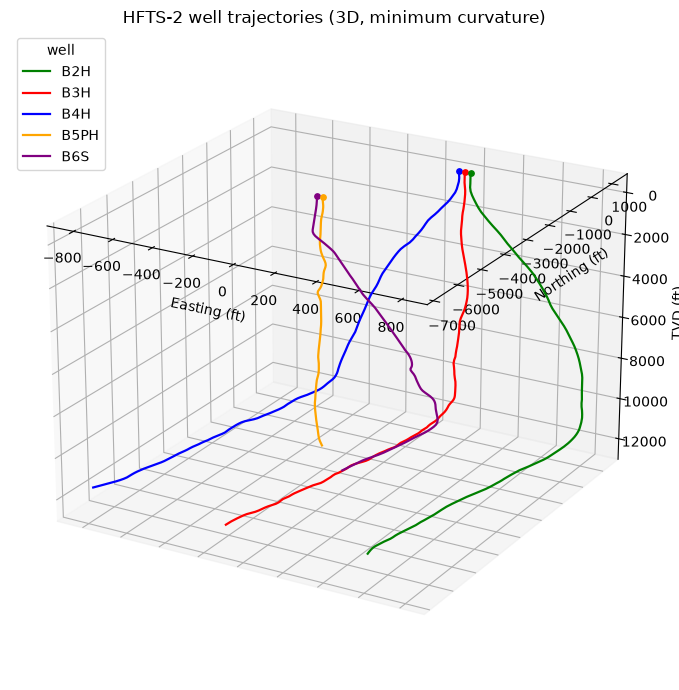

In [6]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")
colors = dict(zip(WELLS, _colors))
for w, v in wells.items():
    ax.plot(v["Et"], v["Nt"], v["TVD"], color=colors[w], lw=1.6, label=w)
    ax.scatter(v["Et"][0], v["Nt"][0], v["TVD"][0], color=colors[w], s=15)   # wellhead
ax.set_xlabel("Easting (ft)")
ax.set_ylabel("Northing (ft)")
ax.set_zlabel("TVD (ft)")
ax.invert_zaxis()
ax.legend(title="well", loc="upper left")
ax.set_title("HFTS-2 well trajectories (3D, minimum curvature)")
ax.view_init(elev=22, azim=-60)
fig.tight_layout(); plt.show()

## Plan (map) view and vertical section

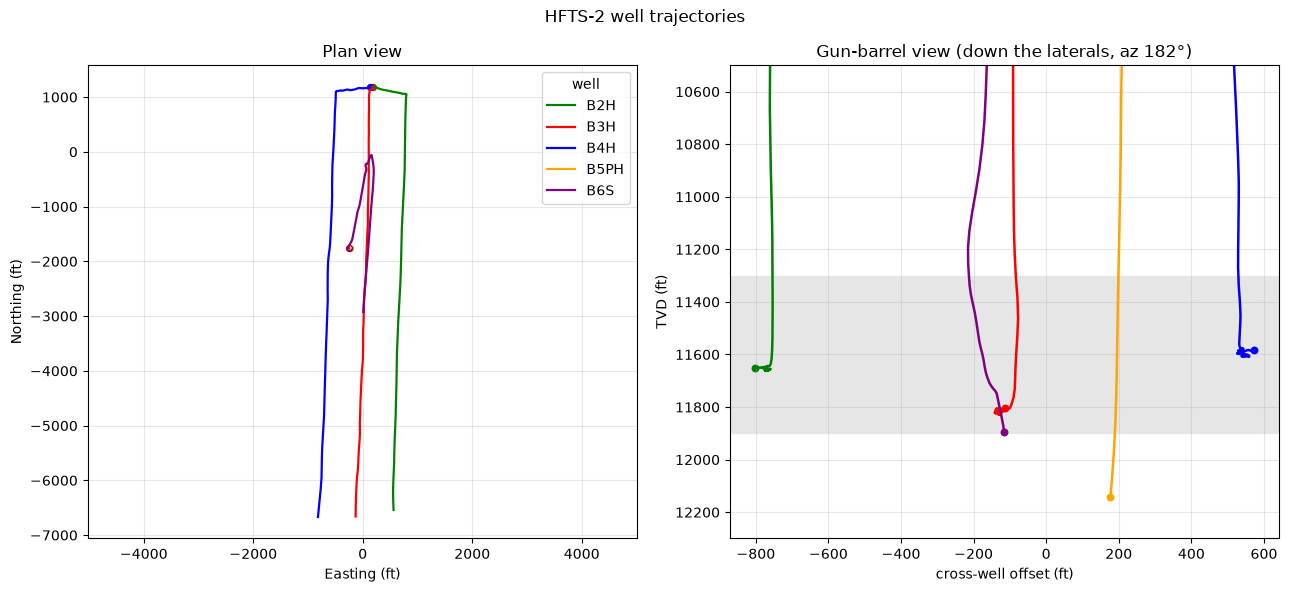

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
tgt = (11300, 11900)   # Wolfcamp target band, TVD ft

# --- left: plan (map) view ---
for w, v in wells.items():
    ax[0].plot(v["Et"], v["Nt"], color=colors[w], lw=1.6, label=w)
    ax[0].scatter(v["Et"][0], v["Nt"][0], color=colors[w], s=18)
ax[0].set_xlabel("Easting (ft)")
ax[0].set_ylabel("Northing (ft)")
ax[0].set_title("Plan view")
ax[0].axis("equal")
ax[0].grid(alpha=0.3)
ax[0].legend(title="well")

# --- right: gun-barrel view (looking down the lateral azimuth) ---
heads = [np.degrees(np.arctan2(wells[w]["E"][-1]-wells[w]["E"][0],
                               wells[w]["N"][-1]-wells[w]["N"][0])) % 360
         for w in ("B1H", "B2H", "B3H", "B4H") if w in wells]
phi = np.radians(np.mean(heads))                       # mean lateral heading
ax[1].axhspan(*tgt, color="0.9", zorder=0, label="Wolfcamp target")
for w, v in wells.items():
    perp = v["Et"]*np.cos(phi) - v["Nt"]*np.sin(phi)   # cross-well offset (ft)
    ax[1].plot(perp, v["TVD"], color=colors[w], lw=1.8, label=w)
    ax[1].scatter(perp[-1], v["TVD"][-1], color=colors[w], s=22)
ax[1].set_xlabel("cross-well offset (ft)")
ax[1].set_ylabel("TVD (ft)")
ax[1].set_title(f"Gun-barrel view (down the laterals, az {np.degrees(phi):.0f}°)")
ax[1].set_ylim(12300, 10500)                           # focus on the completion interval
ax[1].grid(alpha=0.3)

fig.suptitle("HFTS-2 well trajectories"); fig.tight_layout(); plt.show()

## Save the plan/section figure

In [8]:
# saved next to the notebook; the thesis copy lives in thesis_drafts/figures/
fig.savefig(BASE_FIG_DIR + "well_trajectories_3d.png", dpi=150)
print(f"saved well_trajectories_3d.pdf {BASE_FIG_DIR}well_trajectories_3d.png")

saved well_trajectories_3d.pdf ../figures/well_trajectories_3d.png
